# New node families, driven by a CuvisPipeline (hyperspectral lentil inspection)

This notebook demonstrates the node families added to **cuvis-ai** on a real `Lentils`
CU3S session. Everything runs **through the framework**: nodes are wired into a
`CuvisPipeline`, the stateful nodes are fitted with `StatisticalTrainer`, and inference
runs with `Predictor`. We never call `node.forward(...)` by hand, matplotlib only renders
the `(node, port)` outputs the pipeline collected (the same pattern as `blood_perfusion.ipynb`).

The scene is a dense bed of lentils that occasionally contains a non-lentil object (a
stone) and patches of background belt. The **inspection pipeline** is a branched DAG:

```
CU3SDataNode ─┬─> SaturatedPixelDetector                 (QC: over-bright pixels)
              └─> SNVCorrection ─┬─> KMeansClusterer      (spectral clustering)
                                 └─> OneClassSVMDetector ─> MultiRangeSlicer   (novelty + severity bands)
```

`KMeansClusterer` and `OneClassSVMDetector` are fitted on a **clean** lentil frame
(measurement 0) with `StatisticalTrainer`, then the whole graph is run on a **test** frame
(measurement 5, which contains the foreign object) with `Predictor`. (A branch could also terminate
in a visualization/sink node such as `ScalarHSVColormapNode` -> `ToVideoNode`, as in
`blood_perfusion.ipynb`.)

Nodes shown: `CU3SDataNode`, `SNVCorrection` (the pretreatment family), `SaturatedPixelDetector`,
`KMeansClusterer`, `OneClassSVMDetector`, `MultiRangeSlicer`. Other shipped nodes are not featured
because this scene does not suit them:
`NNLSUnmixing` needs an `endmembers` input no node emits as a port; `ShapeMorphology` /
`MaskRobustifier` need spatially-separated objects (a dense lentil bed merges into one connected
region, so there is nothing distinct to measure); and the vegetation-index selectors,
`GaussianMixtureClusterer`, and `IntensityThresholdSegmenter` do not match this target.

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from cuvis_ai_dataloader.data import Cu3sDataModule
from loguru import logger as _loguru_logger

from cuvis_ai.node.clustering.kmeans import KMeansClusterer
from cuvis_ai.node.data import CU3SDataNode
from cuvis_ai.node.deciders.multi_range_decider import MultiRangeSlicer
from cuvis_ai.node.preprocessors import SaturatedPixelDetector
from cuvis_ai.node.pretreatments.snv import SNVCorrection
from cuvis_ai.node.svm import OneClassSVMDetector
from cuvis_ai_core.data.public_datasets import PublicDatasets
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import Predictor, StatisticalTrainer

# Quiet noisy third-party logging (cuvis SDK + dataloader) for a clean notebook.
logging.getLogger().setLevel(logging.CRITICAL)
_loguru_logger.remove()

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

W0625 22:51:56.352000 16600 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


device: cuda


## 0. Data

`Lentils` is a registered public dataset; `download_dataset(..., force=False)` is a no-op once
the data is present. `dm(i)` builds a one-frame datamodule for measurement `i` (frame 0 = clean
reference for fitting, frame 5 = test frame with the foreign object).

In [2]:
DATA_DIR = Path("../../data")
PublicDatasets.download_dataset("Lentils", download_path=str(DATA_DIR), force=False)
CU3S = DATA_DIR / "Lentils" / "Lentils_000.cu3s"
assert CU3S.exists(), f"missing {CU3S}"

FIT_FRAME, TEST_FRAME = 0, 5


def dm(measurement_index) -> Cu3sDataModule:
    """One-frame Cu3sDataModule for the given measurement index."""
    return Cu3sDataModule(
        cu3s_file_path=str(CU3S),
        processing_mode="Reflectance",
        batch_size=1,
        measurement_indices=[measurement_index],
    )

Dataset 'Lentils' already exists at ..\..\data\Lentils
Use force=True to re-download.


## 1. Build the inspection pipeline

`pipeline.connect` takes `(out_port, in_port)` tuples and supports branching (one source feeding
several nodes). Connection targets use `.inputs.<port>` because `cube` is both an input and output
port name on `SNVCorrection`.

In [3]:
data = CU3SDataNode(name="data")
saturation = SaturatedPixelDetector(saturation_value=10000.0, name="saturation")  # ~white-ref level
snv = SNVCorrection(name="snv")
kmeans = KMeansClusterer(n_clusters=5, max_iter=200, random_state=0, name="kmeans")
novelty = OneClassSVMDetector(nu=0.05, gamma="scale", name="novelty")
severity = MultiRangeSlicer(edges=[-1.0, -0.5, 0.0], name="severity")  # bands on the signed score

inspect = CuvisPipeline("lentil_inspection")
inspect.connect(
    (data.outputs.cube, saturation.inputs.cube),
    (data.outputs.cube, snv.inputs.cube),
    (snv.outputs.cube, kmeans.inputs.cube),
    (snv.outputs.cube, novelty.inputs.cube),
    (novelty.outputs.scores, severity.inputs.scores),
)
inspect.to(device)
print("nodes:", [n.name for n in inspect.nodes()])

nodes: ['data', 'saturation', 'snv', 'kmeans', 'novelty', 'severity']


## 2. Fit on the clean frame, run on the test frame

`StatisticalTrainer.fit()` fits every `requires_initial_fit` node in the graph (here
`KMeansClusterer` and `OneClassSVMDetector`) on the train split, feeding each node the output of
its ancestors (so both see SNV-corrected pixels). We fit on the clean frame, then run the whole
pipeline on the test frame and collect every node's outputs.

In [4]:
StatisticalTrainer(pipeline=inspect, datamodule=dm(FIT_FRAME)).fit()

out = Predictor(pipeline=inspect, datamodule=dm(TEST_FRAME)).predict(collect_outputs=True)[0]
print("collected ports:", [f"{n}.{p}" for (n, p) in out.keys()])

# Pull the maps the pipeline produced (no node was called by hand).
cube_test = out[("data", "cube")]
wavelengths = np.asarray(out[("data", "wavelengths")]).ravel()
sat_frac = out[("saturation", "scores")][0, :, :, 0].cpu().numpy()
clusters = out[("kmeans", "class_mask")][0].cpu().numpy()
nov_score = out[("novelty", "scores")][0, :, :, 0].cpu().numpy()
nov_outlier = out[("novelty", "decisions")][0, :, :, 0].cpu().numpy()
sev_bands = out[("severity", "class_mask")][0].cpu().numpy()
print("test cube:", tuple(cube_test.shape), "| bands", wavelengths[0], "..", wavelengths[-1], "nm")

Predict [lentil_inspection]:   0%|          | 0/1 [00:00<?, ?batch/s]

collected ports: ['data.cube', 'data.wavelengths', 'data.mask', 'data.mesu_index', 'saturation.scores', 'saturation.decisions', 'snv.cube', 'kmeans.class_mask', 'kmeans.scores', 'novelty.scores', 'novelty.decisions', 'severity.class_mask']
test cube: (1, 1000, 1080, 61) | bands 430 .. 910 nm


## 3. Inspection results

All six panels come from the single pipeline run above. Severity band 0 = strongest novelty (most
negative SVM score) ... band 3 = inlier (lentil-like).

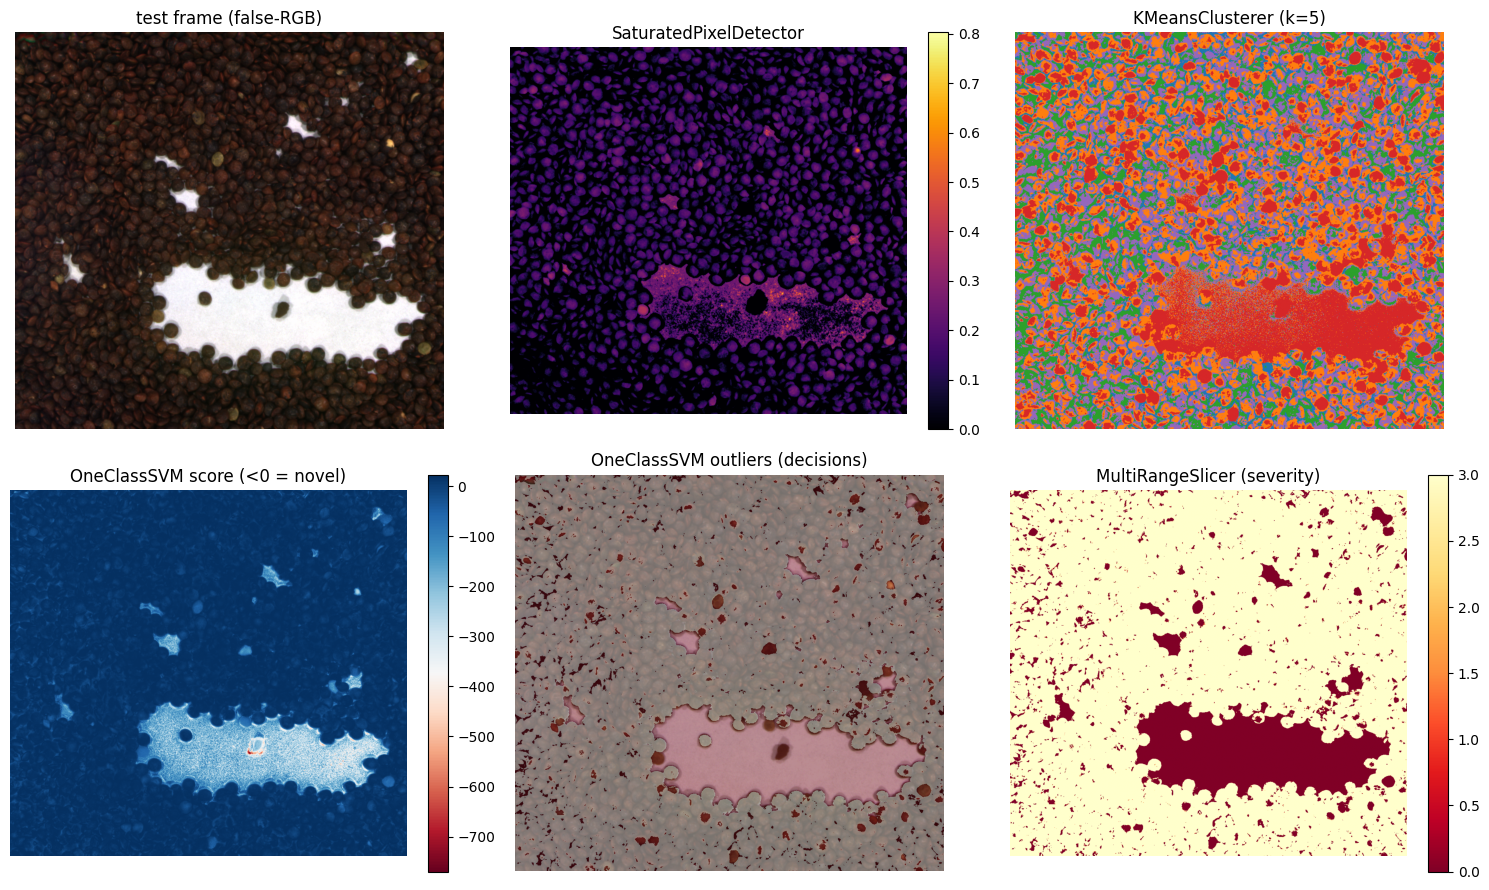

In [5]:
def false_rgb(cube) -> np.ndarray:
    def pick(nm) -> int:
        return int(np.argmin(np.abs(wavelengths - nm)))

    img = cube[0, :, :, [pick(640), pick(550), pick(470)]].cpu().numpy()
    return np.clip(img / max(np.percentile(img, 99), 1e-6), 0, 1)


fig, ax = plt.subplots(2, 3, figsize=(15, 9))

ax[0, 0].imshow(false_rgb(cube_test))
ax[0, 0].set_title("test frame (false-RGB)")

im = ax[0, 1].imshow(sat_frac, cmap="inferno")
ax[0, 1].set_title("SaturatedPixelDetector")
plt.colorbar(im, ax=ax[0, 1], fraction=0.046)

ax[0, 2].imshow(clusters, cmap="tab10", vmin=0, vmax=9)
ax[0, 2].set_title("KMeansClusterer (k=5)")

im = ax[1, 0].imshow(nov_score, cmap="RdBu")
ax[1, 0].set_title("OneClassSVM score (<0 = novel)")
plt.colorbar(im, ax=ax[1, 0], fraction=0.046)

ax[1, 1].imshow(false_rgb(cube_test))
ax[1, 1].imshow(nov_outlier, cmap="Reds", alpha=0.45)
ax[1, 1].set_title("OneClassSVM outliers (decisions)")

im = ax[1, 2].imshow(sev_bands, cmap="YlOrRd_r")
ax[1, 2].set_title("MultiRangeSlicer (severity)")
plt.colorbar(im, ax=ax[1, 2], fraction=0.046)

for a in ax.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

## Notes

- Fitting went through `StatisticalTrainer` and inference through `Predictor`, the same framework
  path a `restore-trainrun` config drives in production.
- The clustering/SVM nodes needed two small fixes to run inside a pipeline on GPU: their `forward`
  must accept the pipeline `context` kwarg and move fitted buffers to the input device (now matching
  `NNLSUnmixing`).
- To wire `NNLSUnmixing` into a pipeline you would add an `endmembers` source (e.g. an `NpyReader`
  of reference spectra); `KMeansClusterer` does not expose its centroids as a port.